# PX4 Phase 1 Closed-Loop Dynamics PINN Training v18 Tracking Error

This notebook retrains the v16 diagnostics baseline with scenario-local north/east position states plus explicit tracking-error features:

- training/validation loss curves
- one-step RMSE/MAE tables and bar charts
- target-vs-predicted parity plots
- real contiguous 80-step rollout trajectory plots including north/east position

Model contract:

```text
x_t, setpoint_t, prev_setpoint_t, dsetpoint_t, dt_s -> dx_t
```

- explicit tracking-error features for recovery regimes (`e_ref_*`)


In [1]:
# Optional in Colab. Safe to skip locally if Drive is already mounted.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Mounted at /content/drive


In [2]:
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

DIAGNOSTIC_FIGURES = []


device: cuda
torch: 2.10.0+cu128


In [3]:
NOTEBOOK_REVISION = 'v18_tracking_error'
DATASET_GLOB_CANDIDATES = [
    '/content/drive/MyDrive/**/px4_phase1_recovery_tracking_error_dataset_v9_*',
    '/content/drive/MyDrive/**/processed/px4_phase1_recovery_tracking_error_dataset_v9_*',
    '/content/**/px4_phase1_recovery_tracking_error_dataset_v9_*',
]
MANUAL_DATASET_DIR = ''  # Set this to a processed v9 dataset directory if auto-search misses it.

BATCH_SIZE = 2048
EPOCHS = 300
LR = 2.5e-3
WEIGHT_DECAY = 2e-4
GRAD_CLIP = 2.0
DROPOUT = 0.04
HIDDEN = 256
DEPTH = 4

# Soft physics terms. Keep these modest; the closed-loop PX4 plant is not a simple rigid-body-only model.
ALT_KIN_WEIGHT = 0.08
YAW_KIN_WEIGHT = 0.03
RATE_SMOOTH_WEIGHT = 0.01


In [4]:
import glob

def find_dataset_dir():
    if MANUAL_DATASET_DIR:
        p = Path(MANUAL_DATASET_DIR)
        if (p / 'train.csv').exists():
            return p
        raise FileNotFoundError(f'MANUAL_DATASET_DIR does not contain train.csv: {p}')
    matches = []
    for pat in DATASET_GLOB_CANDIDATES:
        matches.extend(Path(p) for p in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if (p / 'train.csv').exists()))
    if not matches:
        raise FileNotFoundError('No processed v9 tracking-error dataset found. Run px4_dataset_builder_v9_tracking_error first or set MANUAL_DATASET_DIR.')
    return matches[-1]

DATASET_DIR = find_dataset_dir()
print('DATASET_DIR:', DATASET_DIR)
for name in ['dataset_summary.csv', 'filter_report.csv', 'metadata.json']:
    p = DATASET_DIR / name
    print(name, p.exists())


DATASET_DIR: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_recovery_tracking_error_dataset_v9_20260510_111046
dataset_summary.csv True
filter_report.csv True
metadata.json True


In [5]:
train_df = pd.read_csv(DATASET_DIR / 'train.csv')
val_df = pd.read_csv(DATASET_DIR / 'val.csv')
test_df = pd.read_csv(DATASET_DIR / 'test.csv')
summary_df = pd.read_csv(DATASET_DIR / 'dataset_summary.csv')
print('rows:', {k: len(v) for k, v in [('train', train_df), ('val', val_df), ('test', test_df)]})
display(summary_df)

STATE_COLS = [
    'local_north_m', 'local_east_m', 'relative_altitude_m',
    'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s',
    'roll_deg', 'pitch_deg', 'yaw_deg',
    'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s',
]
ACTION_COLS = [
    'ref_north_m', 'ref_east_m', 'ref_down_m',
    'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg',
]

ERROR_COLS = [
    'ref_north_m', 'ref_east_m', 'ref_alt_m', 'ref_yaw_deg',
    'ref_vn_m_s', 'ref_ve_m_s', 'ref_vd_m_s',
]
missing_errors = [f'e_{c}' for c in ERROR_COLS if f'e_{c}' not in train_df.columns]
if missing_errors:
    raise ValueError(f'Missing tracking-error columns. Rebuild with px4_dataset_builder_v9_tracking_error: {missing_errors}')

TARGET_COLS = [f'dx_{c}' for c in STATE_COLS]
print('target columns:', TARGET_COLS)


rows: {'train': 33000, 'val': 5633, 'test': 6699}


,split,scenario,samples
0,test,R00_nominal_hold_25m,800
1,test,R01_north_offset_plus1_recover,653
2,test,R02_north_offset_minus1_recover,734
3,test,R03_east_offset_plus1_recover,1216
4,test,R04_east_offset_minus1_recover,597
5,test,R05_altitude_low_recover,898
6,test,R06_altitude_high_recover,211
7,test,R07_yaw_plus10_recover,920
8,test,R08_yaw_minus10_recover,480
9,test,R09_mixed_offset_recover,190


target columns: ['dx_local_north_m', 'dx_local_east_m', 'dx_relative_altitude_m', 'dx_vel_north_m_s', 'dx_vel_east_m_s', 'dx_vel_down_m_s', 'dx_roll_deg', 'dx_pitch_deg', 'dx_yaw_deg', 'dx_roll_rate_rad_s', 'dx_pitch_rate_rad_s', 'dx_yaw_rate_rad_s']


In [6]:
def angle_sin_deg(s):
    return np.sin(np.deg2rad(pd.to_numeric(s, errors='coerce').to_numpy(dtype=np.float32)))

def angle_cos_deg(s):
    return np.cos(np.deg2rad(pd.to_numeric(s, errors='coerce').to_numpy(dtype=np.float32)))

def make_features(df):
    parts = []
    names = []

    # Current state. Use sin/cos for yaw to avoid discontinuity at +/-180 deg.
    for col in STATE_COLS:
        src = f'x_{col}'
        if col == 'yaw_deg':
            parts.append(angle_sin_deg(df[src])[:, None]); names.append('x_yaw_sin')
            parts.append(angle_cos_deg(df[src])[:, None]); names.append('x_yaw_cos')
        else:
            parts.append(pd.to_numeric(df[src], errors='coerce').to_numpy(dtype=np.float32)[:, None]); names.append(src)

    # Current, previous, and delta setpoints. Encode yaw references cyclically.
    for prefix in ['u_', 'prev_u_', 'du_']:
        for col in ACTION_COLS:
            src = prefix + col
            if col == 'ref_yaw_deg' and prefix != 'du_':
                parts.append(angle_sin_deg(df[src])[:, None]); names.append(src + '_sin')
                parts.append(angle_cos_deg(df[src])[:, None]); names.append(src + '_cos')
            else:
                values = pd.to_numeric(df[src], errors='coerce').to_numpy(dtype=np.float32)
                if col == 'ref_yaw_deg':
                    values = ((values + 180.0) % 360.0) - 180.0
                parts.append(values[:, None]); names.append(src)

    # Explicit tracking-error features from v9. These make recovery states visible:
    # current state can be displaced while the PX4 setpoint is unchanged.
    for col in ERROR_COLS:
        src = f'e_{col}'
        values = pd.to_numeric(df[src], errors='coerce').to_numpy(dtype=np.float32)
        if col == 'ref_yaw_deg':
            values = ((values + 180.0) % 360.0) - 180.0
        parts.append(values[:, None]); names.append(src)

    parts.append(pd.to_numeric(df['dt_s'], errors='coerce').to_numpy(dtype=np.float32)[:, None]); names.append('dt_s')
    X = np.concatenate(parts, axis=1).astype(np.float32)
    return X, names

def make_targets(df):
    Y = np.stack([pd.to_numeric(df[c], errors='coerce').to_numpy(dtype=np.float32) for c in TARGET_COLS], axis=1)
    return Y.astype(np.float32)

X_train, FEATURE_COLS = make_features(train_df)
X_val, _ = make_features(val_df)
X_test, _ = make_features(test_df)
Y_train = make_targets(train_df)
Y_val = make_targets(val_df)
Y_test = make_targets(test_df)

print('feature dim:', X_train.shape[1])
print('target dim:', Y_train.shape[1])
print('bad train finite:', np.isfinite(X_train).all(), np.isfinite(Y_train).all())


feature dim: 47
target dim: 12
bad train finite: True True


In [7]:
class Standardizer:
    def __init__(self, x, eps=1e-6):
        self.mean = torch.tensor(np.nanmean(x, axis=0), dtype=torch.float32)
        self.std = torch.tensor(np.nanstd(x, axis=0), dtype=torch.float32).clamp_min(eps)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)
    def to_dict(self):
        return {'mean': self.mean.cpu().numpy().tolist(), 'std': self.std.cpu().numpy().tolist()}

x_scaler = Standardizer(X_train)
y_scaler = Standardizer(Y_train)

def loader_for(X, Y, shuffle):
    Xz = x_scaler.encode(X)
    Yz = y_scaler.encode(Y)
    ds = TensorDataset(Xz, Yz)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False, num_workers=0)

train_loader = loader_for(X_train, Y_train, True)
val_loader = loader_for(X_val, Y_val, False)
test_loader = loader_for(X_test, Y_test, False)


In [8]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

model = ResidualMLP(X_train.shape[1], Y_train.shape[1], HIDDEN, DEPTH, DROPOUT).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR * 0.06)

state_index = {name: i for i, name in enumerate(STATE_COLS)}
target_index = {name: i for i, name in enumerate(TARGET_COLS)}
feature_index = {name: i for i, name in enumerate(FEATURE_COLS)}


In [9]:
def denorm_x(xz):
    return x_scaler.decode(xz)

def denorm_y(yz):
    return y_scaler.decode(yz)

def physics_losses(xz, pred_yz):
    x = denorm_x(xz)
    dy = denorm_y(pred_yz)
    dt = x[:, feature_index['dt_s']].clamp_min(1e-3)

    # relative_altitude_dot ~= -vel_down in NED coordinates. Use midpoint velocity.
    dx_h = dy[:, target_index['dx_relative_altitude_m']]
    vdown = x[:, feature_index['x_vel_down_m_s']]
    dvdown = dy[:, target_index['dx_vel_down_m_s']]
    vdown_mid = vdown + 0.5 * dvdown
    alt_res = dx_h / dt + vdown_mid
    alt_loss = torch.mean(alt_res ** 2)

    # small-angle yaw kinematic prior; deliberately weak for multicopter closed-loop data.
    dx_yaw_rad = torch.deg2rad(dy[:, target_index['dx_yaw_deg']])
    yaw_rate = x[:, feature_index['x_yaw_rate_rad_s']]
    yaw_res = dx_yaw_rad / dt - yaw_rate
    yaw_loss = torch.mean(yaw_res ** 2)

    rate_cols = ['dx_roll_rate_rad_s', 'dx_pitch_rate_rad_s', 'dx_yaw_rate_rad_s']
    rate_loss = torch.stack([dy[:, target_index[c]].pow(2).mean() for c in rate_cols]).mean()
    return alt_loss, yaw_loss, rate_loss

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals = {'loss': 0.0, 'data': 0.0, 'alt': 0.0, 'yaw': 0.0, 'rate': 0.0, 'n': 0}
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train_mode:
            opt.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train_mode):
            pred = model(xb)
            data_loss = torch.mean((pred - yb) ** 2)
            alt_loss, yaw_loss, rate_loss = physics_losses(xb, pred)
            loss = data_loss + ALT_KIN_WEIGHT * alt_loss + YAW_KIN_WEIGHT * yaw_loss + RATE_SMOOTH_WEIGHT * rate_loss
            if train_mode:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
        bs = xb.shape[0]
        totals['loss'] += float(loss.detach().cpu()) * bs
        totals['data'] += float(data_loss.detach().cpu()) * bs
        totals['alt'] += float(alt_loss.detach().cpu()) * bs
        totals['yaw'] += float(yaw_loss.detach().cpu()) * bs
        totals['rate'] += float(rate_loss.detach().cpu()) * bs
        totals['n'] += bs
    return {k: v / max(totals['n'], 1) for k, v in totals.items() if k != 'n'}


In [10]:
best_val = float('inf')
best_state = None
history = []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step()
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}, 'lr': scheduler.get_last_lr()[0]}
    history.append(row)
    if va['loss'] < best_val:
        best_val = va['loss']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch == 1 or epoch % 20 == 0:
        print(f"epoch {epoch:04d} train={tr['loss']:.5f} val={va['loss']:.5f} data={va['data']:.5f} alt={va['alt']:.5f} yaw={va['yaw']:.5f}")

if best_state is not None:
    model.load_state_dict(best_state)
print('best val:', best_val, 'elapsed min:', round((time.time() - t0) / 60, 2))
history_df = pd.DataFrame(history)
display(history_df.tail())


epoch 0001 train=0.69744 val=0.43926 data=0.43889 alt=0.00454 yaw=0.00014
epoch 0020 train=0.10421 val=0.09421 data=0.09397 alt=0.00293 yaw=0.00013
epoch 0040 train=0.08353 val=0.07918 data=0.07895 alt=0.00288 yaw=0.00012
epoch 0060 train=0.07890 val=0.07487 data=0.07463 alt=0.00293 yaw=0.00011
epoch 0080 train=0.08840 val=0.08895 data=0.08872 alt=0.00272 yaw=0.00011
epoch 0100 train=0.07154 val=0.06999 data=0.06975 alt=0.00298 yaw=0.00010
epoch 0120 train=0.06976 val=0.06839 data=0.06813 alt=0.00315 yaw=0.00013
epoch 0140 train=0.06833 val=0.06659 data=0.06633 alt=0.00317 yaw=0.00014
epoch 0160 train=0.06696 val=0.06771 data=0.06746 alt=0.00314 yaw=0.00012
epoch 0180 train=0.06425 val=0.06874 data=0.06848 alt=0.00321 yaw=0.00013
epoch 0200 train=0.06311 val=0.06937 data=0.06910 alt=0.00322 yaw=0.00013
epoch 0220 train=0.06588 val=0.06815 data=0.06788 alt=0.00329 yaw=0.00012
epoch 0240 train=0.06018 val=0.06821 data=0.06795 alt=0.00323 yaw=0.00013
epoch 0260 train=0.05914 val=0.06733 d

,epoch,train_loss,train_data,train_alt,train_yaw,train_rate,val_loss,val_data,val_alt,val_yaw,val_rate,lr
295,296,0.057892,0.057606,0.003526,0.000102,0.000075,0.068294,0.068030,0.003240,0.000125,0.000080,0.000151
296,297,0.057938,0.057650,0.003553,0.000102,0.000076,0.068027,0.067762,0.003254,0.000124,0.000079,0.000151
297,298,0.057822,0.057536,0.003532,0.000102,0.000076,0.068126,0.067862,0.003247,0.000125,0.000080,0.000150
298,299,0.057685,0.057399,0.003528,0.000103,0.000076,0.068397,0.068133,0.003244,0.000124,0.000080,0.000150
299,300,0.058201,0.057915,0.003527,0.000100,0.000076,0.068780,0.068517,0.003230,0.000125,0.000080,0.000150


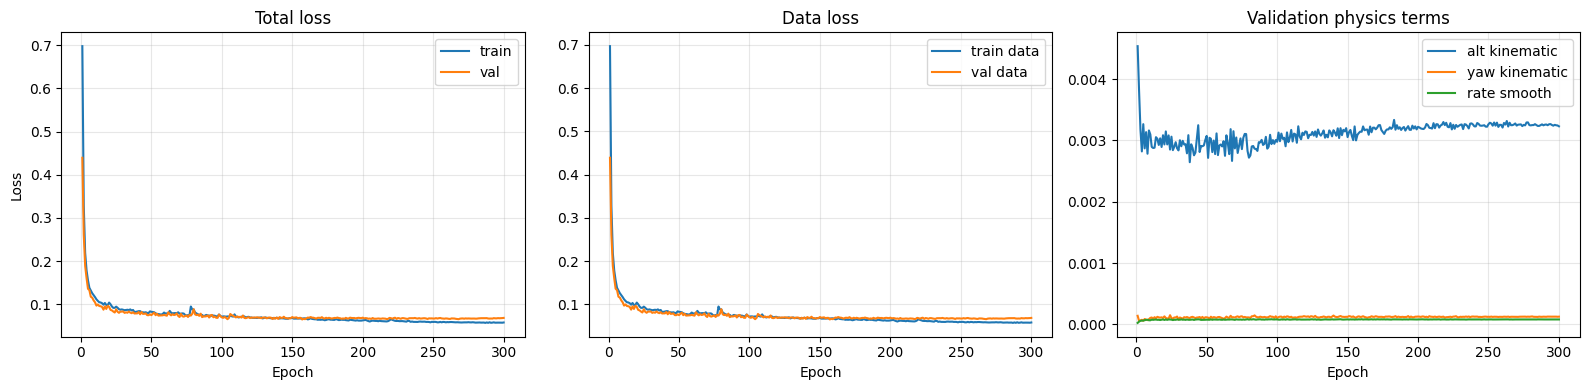

In [11]:
# Visual diagnostics: training curves
fig_loss, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[0].set_title('Total loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_data'], label='train data')
axes[1].plot(history_df['epoch'], history_df['val_data'], label='val data')
axes[1].set_title('Data loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_alt'], label='alt kinematic')
axes[2].plot(history_df['epoch'], history_df['val_yaw'], label='yaw kinematic')
axes[2].plot(history_df['epoch'], history_df['val_rate'], label='rate smooth')
axes[2].set_title('Validation physics terms')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
fig_loss.tight_layout()
DIAGNOSTIC_FIGURES.append(('loss_curves', fig_loss))
plt.show()


In [12]:
@torch.no_grad()
def predict_denorm(X):
    model.eval()
    Xz = x_scaler.encode(X).to(device)
    preds = []
    for i in range(0, len(Xz), 8192):
        yz = model(Xz[i:i+8192])
        preds.append(denorm_y(yz).cpu().numpy())
    return np.concatenate(preds, axis=0)

def metric_table(name, X, Y):
    P = predict_denorm(X)
    rows = []
    for i, col in enumerate(TARGET_COLS):
        err = P[:, i] - Y[:, i]
        rows.append({
            'split': name,
            'target': col.replace('dx_', ''),
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(Y[:, i])),
        })
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    metric_table('train', X_train, Y_train),
    metric_table('val', X_val, Y_val),
    metric_table('test', X_test, Y_test),
], ignore_index=True)
display(metrics_df)


,split,target,rmse,mae,std_true
0,train,local_north_m,0.000179,0.000106,0.003294
1,train,local_east_m,0.000264,0.000164,0.005078
2,train,relative_altitude_m,0.001043,0.000640,0.004102
3,train,vel_north_m_s,0.003628,0.002174,0.010092
4,train,vel_east_m_s,0.003922,0.002479,0.011921
5,train,vel_down_m_s,0.003382,0.001202,0.008088
6,train,roll_deg,0.012551,0.005684,0.127636
7,train,pitch_deg,0.015534,0.007188,0.150585
8,train,yaw_deg,0.011170,0.005653,0.070950
9,train,roll_rate_rad_s,0.002841,0.001313,0.010018


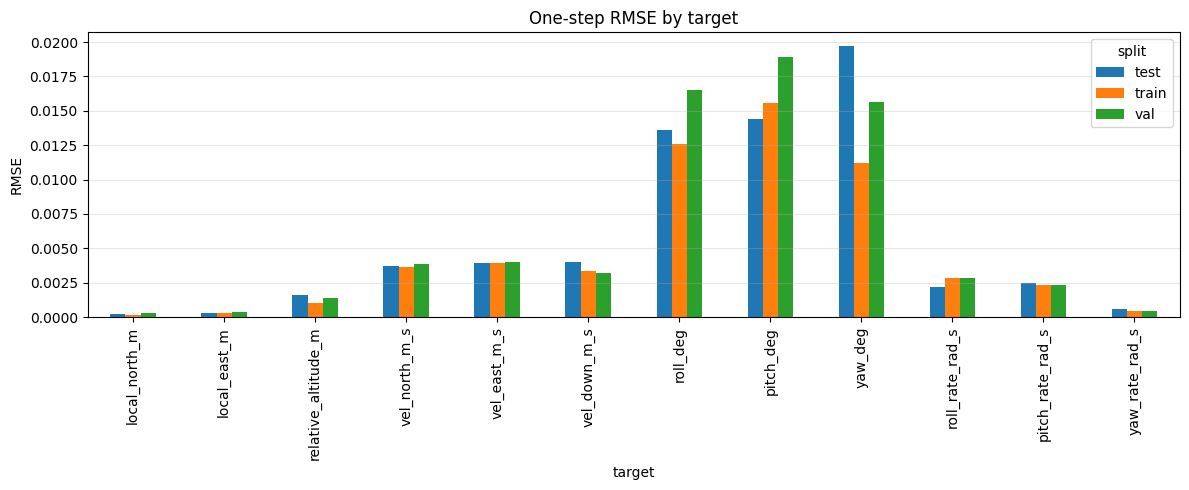

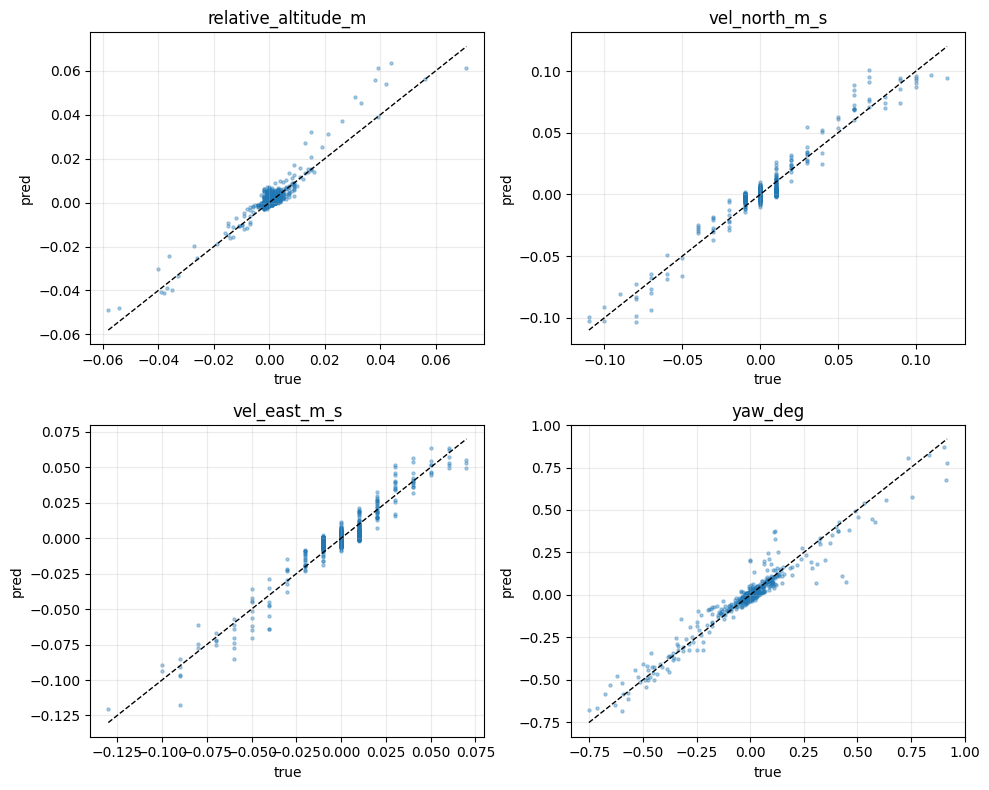

In [13]:
# Visual diagnostics: one-step metric bars and parity plots
metric_pivot = metrics_df.pivot(index='target', columns='split', values='rmse').loc[[c.replace('dx_', '') for c in TARGET_COLS]]
fig_rmse, ax = plt.subplots(figsize=(12, 5))
metric_pivot.plot(kind='bar', ax=ax)
ax.set_title('One-step RMSE by target')
ax.set_ylabel('RMSE')
ax.grid(True, axis='y', alpha=0.3)
fig_rmse.tight_layout()
DIAGNOSTIC_FIGURES.append(('one_step_rmse', fig_rmse))
plt.show()

# Parity plots for targets that matter most for the next MPC step.
P_test = predict_denorm(X_test)
parity_targets = ['dx_relative_altitude_m', 'dx_vel_north_m_s', 'dx_vel_east_m_s', 'dx_yaw_deg']
fig_parity, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, target in zip(axes.ravel(), parity_targets):
    i = TARGET_COLS.index(target)
    y_true = Y_test[:, i]
    y_pred = P_test[:, i]
    n = min(len(y_true), 4000)
    idx = np.linspace(0, len(y_true) - 1, n).astype(int)
    ax.scatter(y_true[idx], y_pred[idx], s=5, alpha=0.35)
    lo = float(min(y_true[idx].min(), y_pred[idx].min()))
    hi = float(max(y_true[idx].max(), y_pred[idx].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(target.replace('dx_', ''))
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
    ax.grid(True, alpha=0.25)
fig_parity.tight_layout()
DIAGNOSTIC_FIGURES.append(('one_step_parity', fig_parity))
plt.show()


,scenario,ref_label,block_id,horizon,north_rmse_m,east_rmse_m,xy_rmse_m,alt_rmse_m,vn_rmse_m_s,ve_rmse_m_s,yaw_rmse_deg
0,R00_nominal_hold_25m,nominal_hold,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.018460,0.012798,0.022462,0.011920,0.019197,0.018025,0.133749
1,R01_north_offset_plus1_recover,recover_center,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.012268,0.014024,0.018632,0.022344,0.019492,0.022372,0.182432
2,R03_east_offset_plus1_recover,pre_hold_center,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.005483,0.005758,0.007951,0.026565,0.010630,0.006747,0.064047
3,R04_east_offset_minus1_recover,final_hold_center,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.005734,0.007362,0.009332,0.008521,0.015594,0.016685,0.059481
4,R05_altitude_low_recover,final_hold_25m,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.005120,0.016656,0.017425,0.013557,0.019407,0.010256,0.105382
5,R07_yaw_plus10_recover,recover_yaw0,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.005619,0.024979,0.025603,0.017117,0.014271,0.029364,0.089670
6,R09_mixed_offset_recover,displace_ne_up_yaw,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.015521,0.012761,0.020093,0.036437,0.036850,0.060798,0.377741
7,R00_nominal_hold_25m,nominal_hold,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.002918,0.003987,0.004941,0.022249,0.005779,0.011714,0.274803
8,R01_north_offset_plus1_recover,recover_center,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.037447,0.034333,0.050804,0.008625,0.043656,0.035881,0.133236
9,R02_north_offset_minus1_recover,recover_center,px4_phase1_standard_vtol_recovery_tracking_err...,80,0.007743,0.007718,0.010933,0.011408,0.018378,0.008691,0.079621


rollout means:


,horizon,north_rmse_m,east_rmse_m,xy_rmse_m,alt_rmse_m,vn_rmse_m_s,ve_rmse_m_s,yaw_rmse_deg
mean,80.0,0.011295,0.012641,0.017961,0.025129,0.018825,0.018727,0.178322


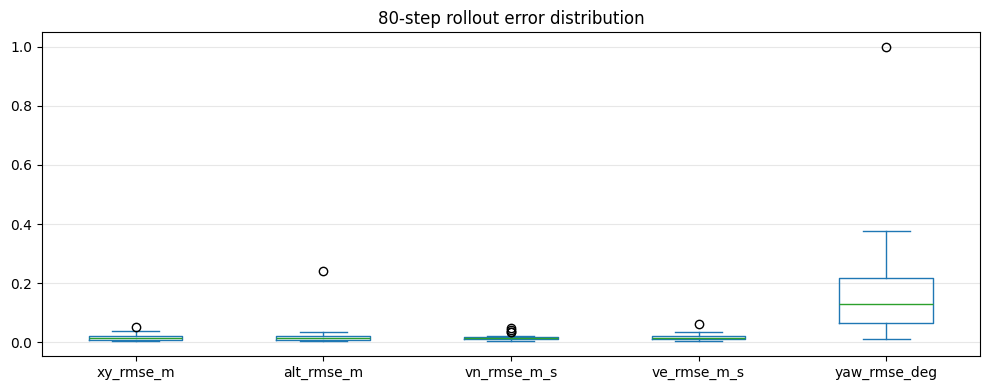

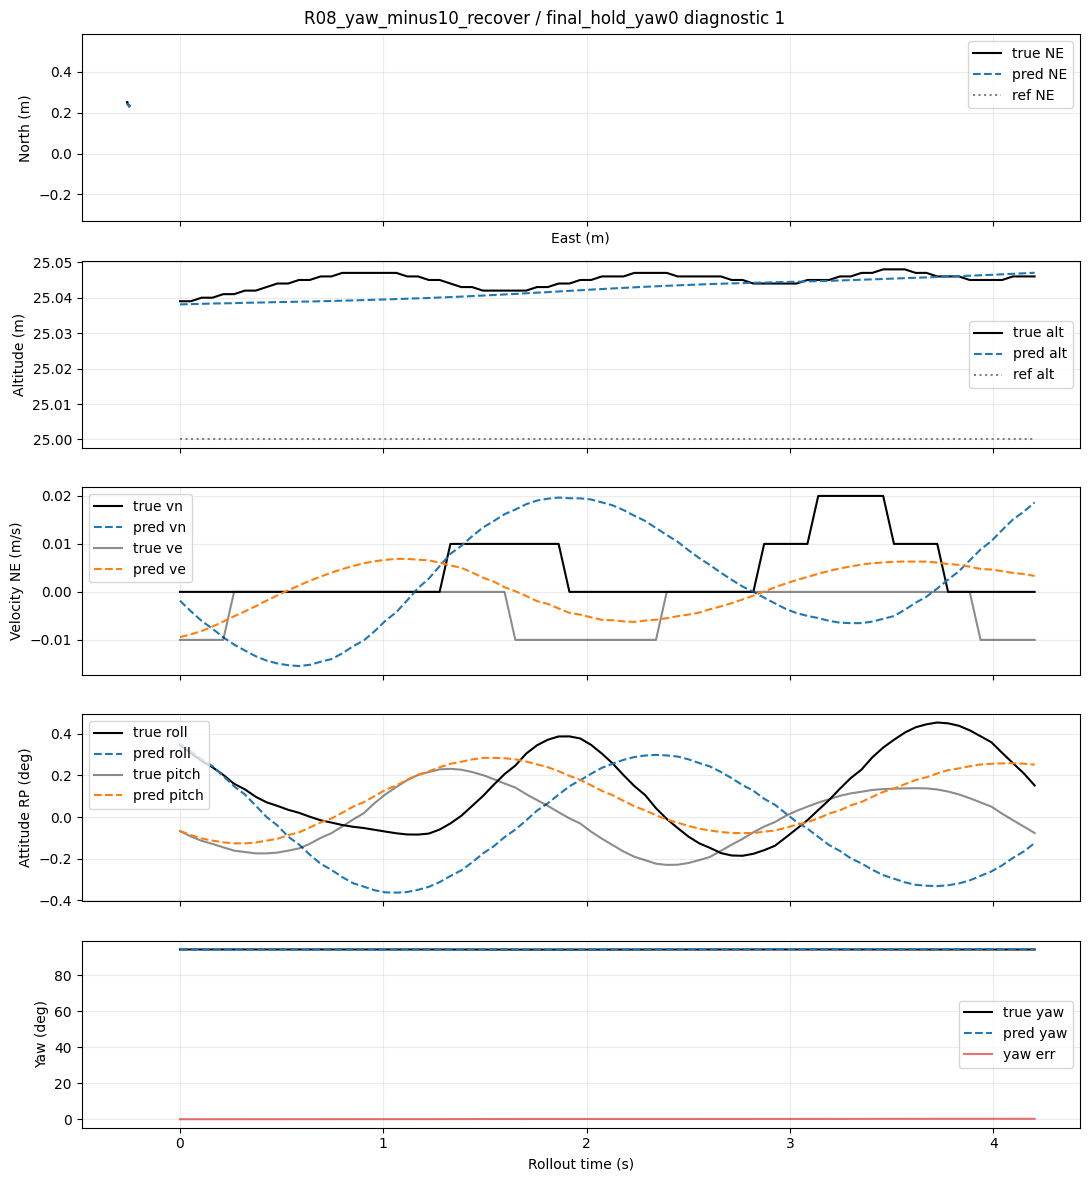

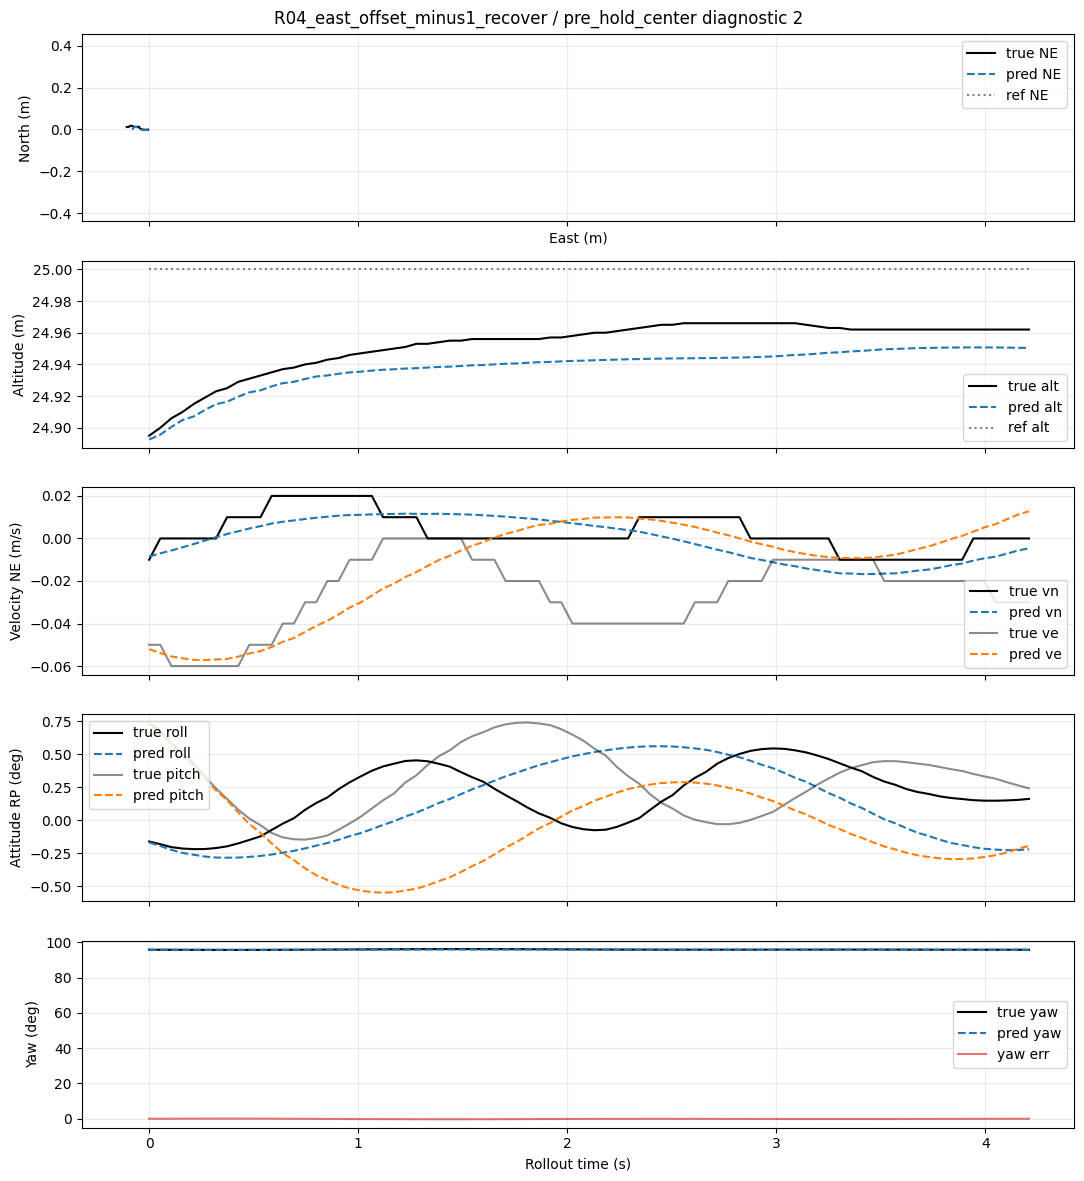

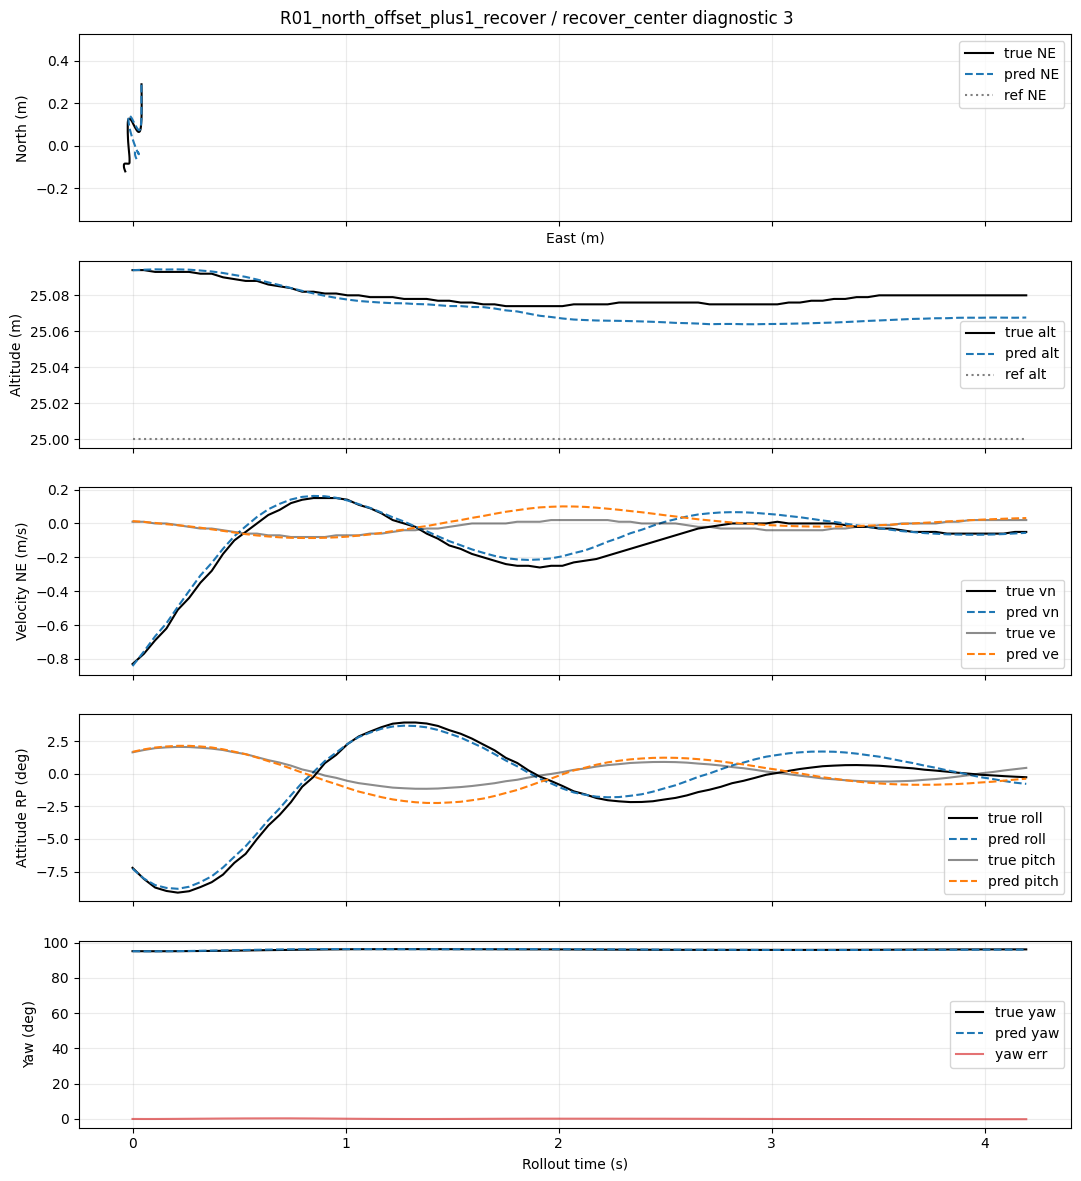

In [14]:
def rollout_segments(df, max_segments=24, horizon=80):
    # v8 keeps block_id-contiguous test windows, so rollout can evaluate real
    # consecutive trajectories instead of stitched random rows.
    out = []
    if 'block_id' in df.columns:
        group_cols = ['source_run', 'scenario', 'block_id'] if 'source_run' in df.columns else ['scenario', 'block_id']
    else:
        group_cols = ['source_run', 'scenario'] if 'source_run' in df.columns else ['scenario']
    ordered = df.sort_values([c for c in [*group_cols, 'sample_index'] if c in df.columns])
    for _, g in ordered.groupby(group_cols):
        g = g.sort_values('sample_index')
        sample_idx = g['sample_index'].to_numpy()
        start = 0
        for j in range(1, len(g) + 1):
            end_block = (j == len(g)) or (sample_idx[j] != sample_idx[j - 1] + 1)
            if end_block:
                block = g.iloc[start:j]
                if len(block) >= horizon:
                    out.append(block.iloc[:horizon].copy())
                    if len(out) >= max_segments:
                        return out
                start = j
    return out

@torch.no_grad()
def rollout_predict(segment):
    cur = segment.iloc[0].copy()
    pred_states = []
    true_states = []
    for k in range(len(segment)):
        row = segment.iloc[k].copy()
        for c in STATE_COLS:
            row[f'x_{c}'] = cur[f'x_{c}']
        Xk, _ = make_features(pd.DataFrame([row]))
        dx = predict_denorm(Xk)[0]
        next_state = {}
        for i, c in enumerate(STATE_COLS):
            value = float(cur[f'x_{c}'] + dx[i])
            if c == 'yaw_deg':
                value = ((value + 180.0) % 360.0) - 180.0
            next_state[f'x_{c}'] = value
        pred_states.append([next_state[f'x_{c}'] for c in STATE_COLS])
        true_states.append([segment.iloc[k][f'x_next_{c}'] for c in STATE_COLS])
        cur = pd.Series(next_state)
    return np.asarray(pred_states), np.asarray(true_states, dtype=np.float32)

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def yaw_rmse_deg(pred, true):
    err = ((np.asarray(pred) - np.asarray(true) + 180.0) % 360.0) - 180.0
    return float(np.sqrt(np.mean(err ** 2)))

def rollout_error(segment):
    P, T = rollout_predict(segment)
    ix = state_index
    north_rmse = rmse(P[:, ix['local_north_m']], T[:, ix['local_north_m']])
    east_rmse = rmse(P[:, ix['local_east_m']], T[:, ix['local_east_m']])
    return {
        'scenario': str(segment.iloc[0]['scenario']),
        'ref_label': str(segment.iloc[0]['ref_label']),
        'block_id': str(segment.iloc[0].get('block_id', '')),
        'horizon': len(segment),
        'north_rmse_m': north_rmse,
        'east_rmse_m': east_rmse,
        'xy_rmse_m': float(np.sqrt(north_rmse ** 2 + east_rmse ** 2)),
        'alt_rmse_m': rmse(P[:, ix['relative_altitude_m']], T[:, ix['relative_altitude_m']]),
        'vn_rmse_m_s': rmse(P[:, ix['vel_north_m_s']], T[:, ix['vel_north_m_s']]),
        've_rmse_m_s': rmse(P[:, ix['vel_east_m_s']], T[:, ix['vel_east_m_s']]),
        'yaw_rmse_deg': yaw_rmse_deg(P[:, ix['yaw_deg']], T[:, ix['yaw_deg']]),
    }

def plot_rollout_segment(segment, title_suffix=''):
    P, T = rollout_predict(segment)
    ix = state_index
    t = np.arange(len(segment)) * float(segment['dt_s'].median())
    fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)
    fig.suptitle(f"{segment.iloc[0]['scenario']} / {segment.iloc[0]['ref_label']} {title_suffix}")

    axes[0].plot(T[:, ix['local_east_m']], T[:, ix['local_north_m']], 'k-', label='true NE')
    axes[0].plot(P[:, ix['local_east_m']], P[:, ix['local_north_m']], 'tab:blue', ls='--', label='pred NE')
    if {'u_ref_east_m', 'u_ref_north_m'}.issubset(segment.columns):
        axes[0].plot(segment['u_ref_east_m'].to_numpy(), segment['u_ref_north_m'].to_numpy(), '0.5', ls=':', label='ref NE')
    axes[0].set_ylabel('North (m)')
    axes[0].set_xlabel('East (m)')
    axes[0].axis('equal')

    axes[1].plot(t, T[:, ix['relative_altitude_m']], 'k-', label='true alt')
    axes[1].plot(t, P[:, ix['relative_altitude_m']], 'tab:blue', ls='--', label='pred alt')
    if 'u_ref_down_m' in segment:
        axes[1].plot(t, -segment['u_ref_down_m'].to_numpy(), '0.5', ls=':', label='ref alt')
    axes[1].set_ylabel('Altitude (m)')

    axes[2].plot(t, T[:, ix['vel_north_m_s']], 'k-', label='true vn')
    axes[2].plot(t, P[:, ix['vel_north_m_s']], 'tab:blue', ls='--', label='pred vn')
    axes[2].plot(t, T[:, ix['vel_east_m_s']], 'k-', alpha=0.45, label='true ve')
    axes[2].plot(t, P[:, ix['vel_east_m_s']], 'tab:orange', ls='--', label='pred ve')
    axes[2].set_ylabel('Velocity NE (m/s)')

    axes[3].plot(t, T[:, ix['roll_deg']], 'k-', label='true roll')
    axes[3].plot(t, P[:, ix['roll_deg']], 'tab:blue', ls='--', label='pred roll')
    axes[3].plot(t, T[:, ix['pitch_deg']], 'k-', alpha=0.45, label='true pitch')
    axes[3].plot(t, P[:, ix['pitch_deg']], 'tab:orange', ls='--', label='pred pitch')
    axes[3].set_ylabel('Attitude RP (deg)')

    yaw_err = ((P[:, ix['yaw_deg']] - T[:, ix['yaw_deg']] + 180.0) % 360.0) - 180.0
    axes[4].plot(t, T[:, ix['yaw_deg']], 'k-', label='true yaw')
    axes[4].plot(t, P[:, ix['yaw_deg']], 'tab:blue', ls='--', label='pred yaw')
    axes[4].plot(t, yaw_err, 'tab:red', alpha=0.65, label='yaw err')
    axes[4].set_ylabel('Yaw (deg)')
    axes[4].set_xlabel('Rollout time (s)')

    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')
    fig.tight_layout()
    return fig

rollout_segs = rollout_segments(test_df, max_segments=24, horizon=80)
roll_rows = [rollout_error(seg) for seg in rollout_segs]
rollout_df = pd.DataFrame(roll_rows)
display(rollout_df)
print('rollout means:')
display(rollout_df.mean(numeric_only=True).to_frame('mean').T if len(rollout_df) else rollout_df)

if len(rollout_df):
    fig_roll_bar, ax = plt.subplots(figsize=(10, 4))
    rollout_df[['xy_rmse_m', 'alt_rmse_m', 'vn_rmse_m_s', 've_rmse_m_s', 'yaw_rmse_deg']].plot(kind='box', ax=ax)
    ax.set_title('80-step rollout error distribution')
    ax.grid(True, axis='y', alpha=0.3)
    fig_roll_bar.tight_layout()
    DIAGNOSTIC_FIGURES.append(('rollout_error_box', fig_roll_bar))
    plt.show()

    selected_indices = []
    selected_indices.append(int(rollout_df['xy_rmse_m'].idxmin()))
    selected_indices.append(int((rollout_df['xy_rmse_m'] - rollout_df['xy_rmse_m'].median()).abs().idxmin()))
    selected_indices.append(int(rollout_df['xy_rmse_m'].idxmax()))
    for rank, idx in enumerate(dict.fromkeys(selected_indices).keys(), start=1):
        fig = plot_rollout_segment(rollout_segs[idx], title_suffix=f"diagnostic {rank}")
        DIAGNOSTIC_FIGURES.append((f'rollout_trace_{rank}', fig))
        plt.show()


In [15]:
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_tracking_error_training_v18')
else:
    SAVE_ROOT = Path('/content/px4_phase1_tracking_error_training_v18')
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
SAVE_DIR = SAVE_ROOT / RUN_STAMP
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ckpt = {
    'revision': NOTEBOOK_REVISION,
    'dataset_dir': str(DATASET_DIR),
    'state_cols': STATE_COLS,
    'action_cols': ACTION_COLS,
    'error_cols': ERROR_COLS,
    'target_cols': TARGET_COLS,
    'feature_cols': FEATURE_COLS,
    'model_config': {'hidden': HIDDEN, 'depth': DEPTH, 'dropout': DROPOUT},
    'model_state_dict': model.cpu().state_dict(),
    'x_scaler': x_scaler.to_dict(),
    'y_scaler': y_scaler.to_dict(),
    'history': history_df.to_dict(orient='records'),
}
torch.save(ckpt, SAVE_DIR / 'px4_tracking_error_dynamics_pinn_v18.pt')
history_df.to_csv(SAVE_DIR / 'training_history.csv', index=False)
metrics_df.to_csv(SAVE_DIR / 'one_step_metrics.csv', index=False)
rollout_df.to_csv(SAVE_DIR / 'rollout_metrics.csv', index=False)
for name, fig in DIAGNOSTIC_FIGURES:
    fig.savefig(SAVE_DIR / f'{name}.png', dpi=160, bbox_inches='tight')
print('saved:', SAVE_DIR)
print('saved figures:', [name for name, _ in DIAGNOSTIC_FIGURES])


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_tracking_error_training_v18/20260510_021955
saved figures: ['loss_curves', 'one_step_rmse', 'one_step_parity', 'rollout_error_box', 'rollout_trace_1', 'rollout_trace_2', 'rollout_trace_3']
